# Nama: I Made Bimantoro Mastra

---

# Assignment: Hypothesis Testing Concepts

## Import Library

- `pandas` untuk membaca dan mengolah data tabel (dataframe)
- `numpy` untuk operasi numerik
- `matplotlib.pyplot` dan `seaborn` untuk membuat visualisasi/grafik
- `scipy.stats` untuk uji statistik (normalitas, varians, t-test)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Supaya grafik seaborn terlihat lebih rapi
sns.set_style('whitegrid')


## 1. Eksplorasi dan Statistik Deskriptif

### 1.1 Tampilkan Struktur Dataset

In [ ]:
# Membaca file dataset.
df = pd.read_csv('/content/sample_data/marketing_campaign.csv', sep='\t') # Memakai seperated tab karna dataset kolomnya dipisahkan oleh tab.

df.head()                                                                 # Menampilkan 5 baris pertama data.


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
df.info() # info() menampilkan jumlah baris, nama kolom, tipe data tiap kolom, dan apakah ada nilai kosong (non-null count)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [ ]:
print("Ukuran dataset:", df.shape)  # shape menampilkan (jumlah baris, jumlah kolom).

print("\nDaftar kolom:")
print(df.columns.tolist())          # columns.tolist() menampilkan semua nama kolom dalam bentuk list.


Ukuran dataset: (2240, 29)

Daftar kolom:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']


### 1.2 Cek Missing Value

Cek data yang kosong untuk tidak mengganggu perhitungan statistik.

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(10) # Df.isnull() mengecek null yang ada di dataframe, sum() menjumlahkan berapa banyak True per kolom kemudian sort_value dari angka terbesar hingga terkecil.


,0
Income,24
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [ ]:
df.shape[0]

2240

In [ ]:
missing_percent = (df.isnull().sum() / len(df)) * 100 # Untuk menghitung jumlah baris kosong per kolom, dibagi total baris, dikali 100 = persentase kosong.
missing_percent.sort_values(ascending=False).head(10) # 10 baris pertama.

,0
Income,1.071429
ID,0.000000
Year_Birth,0.000000
Education,0.000000
Marital_Status,0.000000
Kidhome,0.000000
Teenhome,0.000000
Dt_Customer,0.000000
Recency,0.000000
MntWines,0.000000


kosong < 5% dihapus (`dropna`).

5% <= kosong <= 20-30% mulai perlu pertimbangan, biasanya lebih baik diisi (`fillna` pakai mean/median untuk numerik, atau modus untuk kategori).

kosong > 30-40% data diisi karna datanya sudah terlalu banyak bolongnya untuk diandalkan.

Dari hasil data `income` memiliki 24 baris kosong dan setelah dihitung persentasenya hasilnya dibawah 5% maka akan dihapus karna akan mengganggu perhitungan nanti (`dropna`).

In [ ]:
df = df.dropna(subset=['Income']) # dropna(subset=['Income']) akan menghapus baris yang nilai Income-nya kosong

print("Ukuran dataset setelah menghapus baris Income kosong:", df.shape)


Ukuran dataset setelah menghapus baris Income kosong: (2216, 29)


### 1.3 Identifikasi Variabel Penting

Untuk mencari variabel penting membutuhkan dua hal:
1. **Variabel numerik**
2. **Variabel pengelompokan (grouping)**


In [ ]:
# Daftar kolom pengeluaran per kategori produk, cek semua kolom yang berawalan Mnt/ amount.
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
                  'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

# sum(axis=1) menjumlahkan nilai antar kolom (ke arah samping) untuk tiap baris/pelanggan
df['Total_Spending'] = df[spending_cols].sum(axis=1)

df[spending_cols + ['Total_Spending']].head()


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,Total_Spending
0,635,88,546,172,88,88,1617
1,11,1,6,2,1,6,27
2,426,49,127,111,21,42,776
3,11,4,20,10,3,5,53
4,173,43,118,46,27,15,422


In [ ]:
# (Kidhome + Teenhome) > 0 menghasilkan True jika pelanggan punya minimal 1 anak (kecil atau remaja), False jika tidak
df['Has_Children'] = (df['Kidhome'] + df['Teenhome'] > 0).map({True: 'Punya Anak', False: 'Tidak Punya Anak'})  # .map({...}) mengubah True/False menjadi label teks yang lebih mudah dibaca

df['Has_Children'].value_counts()


,count
Has_Children,
Punya Anak,1583
Tidak Punya Anak,633


In [ ]:
# Cek kategori apa saja yang ada di kolom Education, dan berapa banyak pelanggan di tiap kategori
df['Education'].value_counts()

,count
Education,
Graduation,1116
PhD,481
Master,365
2n Cycle,200
Basic,54


In [ ]:
# Kategori Marital_Status
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,857
Together,573
Single,471
Divorced,232
Widow,76
Alone,3
Absurd,2
YOLO,2


In [ ]:
# Mengganti kategori gak jelas seperti Yolo dan Absurd, dan kategori Alone menjadi Single.
df['Marital_Status_Clean'] = df['Marital_Status'].replace({ # .replace({...}) mengganti nilai-nilai tersebut supaya kategorinya lebih rapi dan konsisten.
    'Alone': 'Single',
    'YOLO': 'Single',
    'Absurd': 'Single'
})

df['Marital_Status_Clean'].value_counts()

,count
Marital_Status_Clean,
Married,857
Together,573
Single,478
Divorced,232
Widow,76


In [ ]:
# Response berisi pelanggan menerima campaign terakhir (1) atau tidak (0).
df['Response_Label'] = df['Response'].map({1: 'Menerima Campaign', 0: 'Tidak Menerima Campaign'}) # .map() mengubah kolom response yang 1/0 menjadi kolom baru (Response_Label) supaya lebih enak dibaca.

df['Response_Label'].value_counts()

,count
Response_Label,
Tidak Menerima Campaign,1883
Menerima Campaign,333


In [ ]:
print("Total spending berdasarkan yang punya Childern:")
print(df.groupby('Has_Children')['Total_Spending'].describe(), "\n")

print("Income berdasarkan Education:")
print(df.groupby('Education')['Income'].describe(), "\n")

print("Total_Spending berdasarkan Marital_Status:")
print(df.groupby('Marital_Status_Clean')['Total_Spending'].describe(), "\n")

print("NumWebPurchases berdasarkan Response:")
print(df.groupby('Response_Label')['NumWebPurchases'].describe(), "\n")


Total spending berdasarkan yang punya Childern:
                   count         mean         std  min    25%     50%     75%  \
Has_Children                                                                    
Punya Anak        1583.0   407.869236  451.055641  5.0   55.0   198.0   661.5   
Tidak Punya Anak   633.0  1105.248025  645.523277  6.0  634.0  1189.0  1588.0   

                     max  
Has_Children              
Punya Anak        2194.0  
Tidak Punya Anak  2525.0   

Income berdasarkan Education:
             count          mean           std     min       25%      50%  \
Education                                                                   
2n Cycle     200.0  47633.190000  22119.081838  7500.0  27526.50  46805.0   
Basic         54.0  20306.259259   6235.066773  7500.0  15405.25  20744.0   
Graduation  1116.0  52720.373656  28177.192681  1730.0  34834.50  52028.5   
Master       365.0  52917.534247  20157.788029  6560.0  37760.00  50943.0   
PhD          481.0  56145

### 1.4 Statistik Deskriptif

In [ ]:
# describe() menghitung count, mean, std, min, max, dan kuartil (25%, 50%, 75%) sekaligus
df[['Income', 'Total_Spending']].describe()


,Income,Total_Spending
count,2216.000000,2216.000000
mean,52247.251354,607.075361
std,25173.076661,602.900476
min,1730.000000,5.000000
25%,35303.000000,69.000000
50%,51381.500000,396.500000
75%,68522.000000,1048.000000
max,666666.000000,2525.000000


In [ ]:
# groupby('Has_Children') mengelompokkan data berdasarkan status anak,
# lalu describe() menghitung statistik deskriptif Total_Spending untuk masing-masing kelompok
df.groupby('Has_Children')['Total_Spending'].describe()


,count,mean,std,min,25%,50%,75%,max
Has_Children,,,,,,,,
Punya Anak,1583.0,407.869236,451.055641,5.0,55.0,198.0,661.5,2194.0
Tidak Punya Anak,633.0,1105.248025,645.523277,6.0,634.0,1189.0,1588.0,2525.0


### 1.5 Visualisasi Distribusi Data

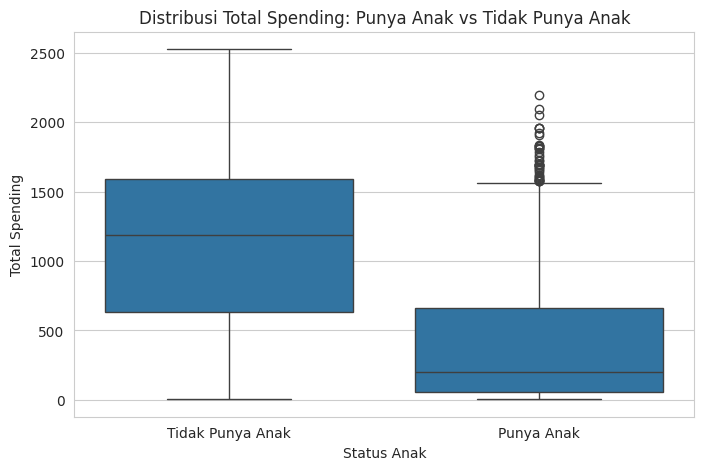

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Has_Children', y='Total_Spending')  # Sumber data dari df, sumbu horizontal X (kategori) pakai kolom Has_Children jadi ada 2 kotak yaitu tidak punya anak dan punya anak, sumbu vertikal Y (angka) pakai kolom Total_Spending
plt.title('Distribusi Total Spending: Punya Anak vs Tidak Punya Anak')
plt.xlabel('Status Anak')
plt.ylabel('Total Spending')
plt.show()


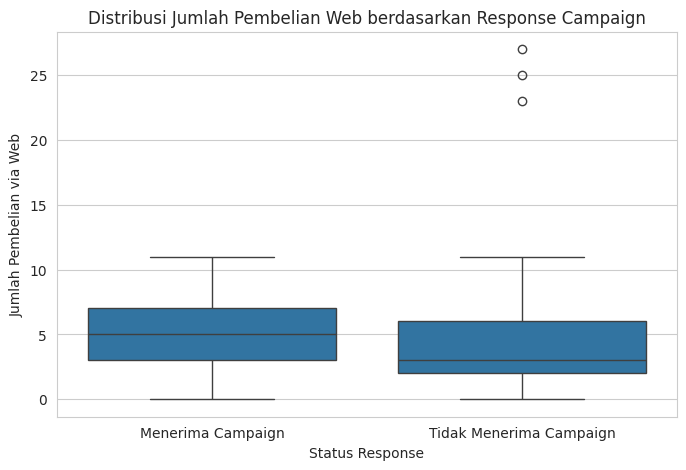

In [ ]:
# Contoh lain
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Response_Label', y='NumWebPurchases')  # Sumber data dari df, sumbu horizontal X (kategori) pakai kolom Response_Label jadi ada 2 kotak yaitu tidak punya anak dan punya anak, sumbu vertikal Y (angka) pakai kolom NumWebPurchases.
plt.title('Distribusi Jumlah Pembelian Web berdasarkan Response Campaign')
plt.xlabel('Status Response')
plt.ylabel('Jumlah Pembelian via Web')
plt.show()

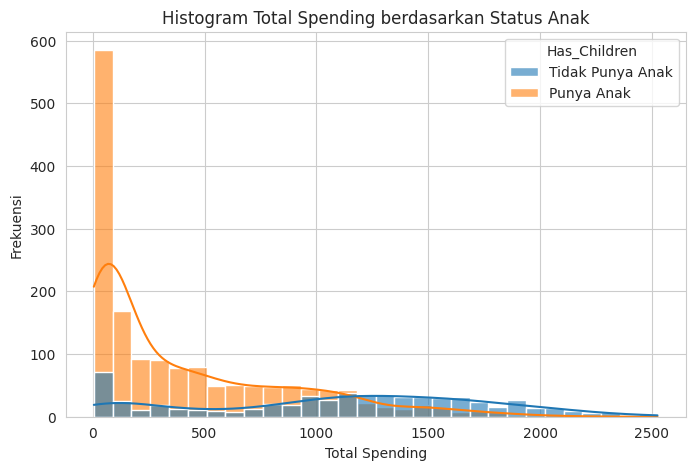

In [ ]:
plt.figure(figsize=(8, 5))                                      # Bikin kanvas kosong untuk grafik, dengan ukuran lebar 8 inci, tinggi 5 inci.
sns.histplot(data=df, x='Total_Spending', hue='Has_Children', kde=True, bins=30, alpha=0.6) # Hue supaya batang milik "Punya Anak" dan "Tidak Punya Anak" bisa dibedakan warnanya dalam grafik yang sama. alpha=0.6 untuk tingkatan transparansi warna batang.
# bins=30 membagi rentang nilai Total_Spending jadi 30 batang/kelompok. Semakin banyak bins, semakin detail jika semakin dikit bins maka hasilnya lebih general.
# kde=True menambahkan garis kurva halus (Kernel Density Estimate) di atas batang histogram, untuk melihat "bentuk" distribusinya.
# Sumbu-x sudah dipakai oleh Total_Spending (nilai numerik yang mau dilihat distribusinya), dan sumbu-y itu otomatis jadi hitungan frekuensi (bawaan histogram, tidak bisa diganti isinya jadi kategori teks).
plt.title('Histogram Total Spending berdasarkan Status Anak')
plt.xlabel('Total Spending')
plt.ylabel('Frekuensi')
plt.show()


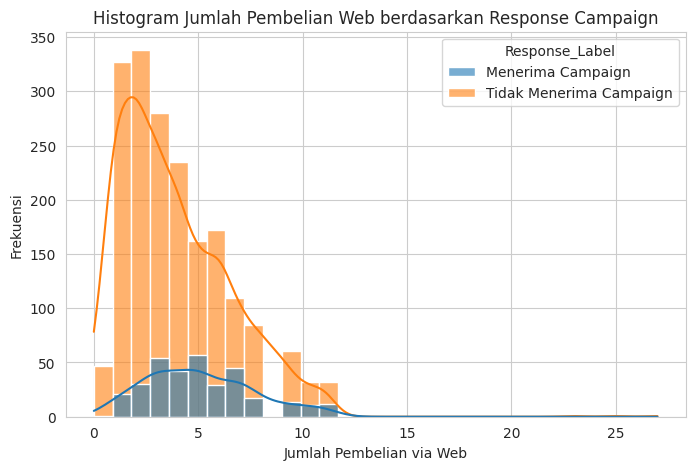

In [ ]:
# Contoh lain
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='NumWebPurchases', hue='Response_Label', kde=True, bins=30, alpha=0.6)
plt.title('Histogram Jumlah Pembelian Web berdasarkan Response Campaign')
plt.xlabel('Jumlah Pembelian via Web')
plt.ylabel('Frekuensi')
plt.show()

### 1.6 Karakteristik Data (Text Cell)

### 1. Ukuran & kebersihan data
Dataset awal punya sekitar 2.240 baris. Setelah menghapus baris dengan Income kosong (±24 baris, hanya ~1% dari total), kosongnya tidak banyak jadi tidak signifikan sehingga tanpa perlu imputasi.
### 2. Distribusi Total_Spending
Dari boxplot dan histogram, terlihat distribusinya menceng ke kanan (right-skewed) dikarenakan ada pelanggan yang pengeluaran sangat tinggi yang menarik "ekor" distribusi ke kanan. Ini juga terlihat dari banyaknya outlier di boxplot kelompok "Punya Anak".
### 3. Perbedaan antar kelompok Has_Children
Pelanggan "Tidak Punya Anak" rata-rata belanja jauh lebih tinggi (mean ≈1105) dibanding pelanggan "Punya Anak" (mean ≈408). Kelompok "Tidak Punya Anak" juga jumlahnya lebih sedikit (633 vs 1583) tapi sebarannya lebih luas (std lebih besar).
### 4. Implikasi untuk uji hipotesis
Karena datanya tidak normal (skewed) tapi jumlah sampelnya besar, jadi memakai Central Limit Theorem supaya uji t-test tetap valid. Perbedaan rata-rata yang cukup besar antar 2 kelompok ini juga jadi indikasi awal bahwa kemungkinan hasil uji hipotesis nanti akan signifikan — tapi tetap perlu dikonfirmasi lewat uji statistik formal, bukan cuma dari statistik deskriptif saja.

## 2. Uji Hipotesis

### 2.1 Tujuan Analisis

**Apakah pelanggan yang punya anak memiliki rata-rata total pengeluaran yang berbeda secara signifikan dibanding pelanggan yang tidak punya anak?**

### 2.2 Rumusan Hipotesis

- **H0 (hipotesis nol):** Tidak ada perbedaan rata-rata Total Spending antara pelanggan yang punya anak dan yang tidak punya anak (μ1 = μ2)
- **H1 (hipotesis alternatif):** Ada perbedaan rata-rata Total Spending antara kedua kelompok (μ1 ≠ μ2)

Tingkat signifikansi yang digunakan: **α = 0.05**

### 2.3 Pemilihan Metode Uji

Karena membandingkan 2 kelompok independen maka metode yang paling sesuai adalah **Independent Samples t-test**.

Sebelum melakukan t-test, kita perlu mengecek 2 asumsi dasarnya:
1. **Normalitas** -> apakah data di tiap kelompok mendekati distribusi normal
2. **Homogenitas varians** -> apakah kedua kelompok punya varians (sebaran) yang kurang lebih sama

In [ ]:
# Memisahkan data Total_Spending menjadi 2 kelompok sesuai status anak
group_punya_anak = df[df['Has_Children'] == 'Punya Anak']['Total_Spending']
group_tidak_anak = df[df['Has_Children'] == 'Tidak Punya Anak']['Total_Spending']

print("Jumlah data 'Punya Anak'   :", len(group_punya_anak))
print("Jumlah data 'Tidak Punya Anak':", len(group_tidak_anak))


Jumlah data 'Punya Anak'   : 1583
Jumlah data 'Tidak Punya Anak': 633


**Cek Normalitas (Shapiro-Wilk Test)**

H0 uji Shapiro-Wilk: data berdistribusi normal. Jika p-value < 0.05, berarti data **tidak normal**. Menggunakan sampel acak 500 data per kelompok agar hasil ujinya valid.

In [ ]:
# random_state=42 supaya hasil sampling selalu sama tiap kali dijalankan (reproducible)
sample_punya_anak = group_punya_anak.sample(500, random_state=42)
sample_tidak_anak = group_tidak_anak.sample(500, random_state=42)

stat1, p_norm1 = stats.shapiro(sample_punya_anak)
stat2, p_norm2 = stats.shapiro(sample_tidak_anak)

print(f"Shapiro-Wilk 'Punya Anak'    : statistik={stat1:.4f}, p-value={p_norm1:.4f}")
print(f"Shapiro-Wilk 'Tidak Punya Anak': statistik={stat2:.4f}, p-value={p_norm2:.4f}")


Shapiro-Wilk 'Punya Anak'    : statistik=0.8008, p-value=0.0000
Shapiro-Wilk 'Tidak Punya Anak': statistik=0.9571, p-value=0.0000


Karena p-value keduanya jauh di bawah 0.05 maka kedua kelompok ini datanya tidak berdistribusi normal. Hasil sudah terlihat dari histogram di bagian eksplorasi, di mana bentuknya miring ke kanan (right-skewed), bukan simetris seperti lonceng.

**Cek Homogenitas Varians (Levene's Test)**

H0 uji Levene: varians kedua kelompok sama. Jika p-value < 0.05, berarti varians **tidak sama (unequal variance)**.

In [ ]:
stat_lev, p_lev = stats.levene(group_punya_anak, group_tidak_anak)
print(f"Levene's Test: statistik={stat_lev:.4f}, p-value={p_lev:.4f}")


Levene's Test: statistik=118.0294, p-value=0.0000


Variansnya tidak sama. Ini juga sama dari boxplot sebelumnya karna kotak "Tidak Punya Anak" jauh lebih "lebar" sebarannya dibanding kotak "Punya Anak" yang lebih rapat di angka rendah.



Data spending di dunia nyata biasanya tidak benar-benar normal (cenderung right-skewed). Namun karena jumlah sampel  **cukup besar (>1000 per kelompok)**, berdasarkan **Central Limit Theorem (CLT)**, distribusi rata-rata sampel tetap akan mendekati normal walaupun data aslinya tidak normal. Karena itu, t-test tetap valid digunakan di sini meskipun uji Shapiro-Wilk menunjukkan data tidak normal.

Untuk homogenitas varians, menggunakan hasil Levene's test untuk menentukan apakah pakai t-test standar (equal_var=True) atau **Welch's t-test** (equal_var=False) yang lebih aman digunakan jika varians kedua kelompok berbeda.

### 2.4 Menjalankan Uji Hipotesis (Independent t-test)

In [ ]:
# equal_var=False -> menggunakan Welch's t-test, yang tidak mengasumsikan varians kedua kelompok sama.
# Ini pilihan yang lebih aman kalau kita tidak yakin/lihat dari Levene's test bahwa variansnya berbeda.
t_stat, p_value = stats.ttest_ind(group_punya_anak, group_tidak_anak, equal_var=False)
# stats.ttest_ind(...) fungsi dari scipy untuk membandingkan rata-rata 2 kelompok independen
# equal_var=False memberitahu fungsi ini untuk tidak mengasumsikan varians kedua kelompok sama, alias pakai versi Welch's t-test. Ini dipilih karena Levene's test sebelumnya sudah membuktikan variansnya memang beda (p-value 0.0000).

print(f"t-statistic : {t_stat:.4f}")  # Menampilkan hasilnya, dibulatkan 4 angka di belakang koma (.4f = format angka desimal 4 digit).
print(f"p-value     : {p_value:.4f}")


t-statistic : -24.8618
p-value     : 0.0000


### 2.5 Keputusan terhadap H0

In [ ]:
alpha = 0.05

if p_value < alpha:
    print(f"p-value ({p_value:.4f}) < alpha ({alpha})")
    print("Keputusan: TOLAK H0")
    print("Artinya: ada perbedaan rata-rata Total Spending yang signifikan secara statistik antara kedua kelompok.")
else:
    print(f"p-value ({p_value:.4f}) >= alpha ({alpha})")
    print("Keputusan: GAGAL TOLAK H0")
    print("Artinya: tidak cukup bukti untuk mengatakan ada perbedaan rata-rata Total Spending antara kedua kelompok.")


p-value (0.0000) < alpha (0.05)
Keputusan: TOLAK H0
Artinya: ada perbedaan rata-rata Total Spending yang signifikan secara statistik antara kedua kelompok.


### 2.6 Text Cell: Alasan Pemilihan Metode & Hasil Uji

**Alasan memilih metode uji ini:**
Independent samples t-test (Welch) dipilih karena kita membandingkan rata-rata sebuah variabel numerik (`Total_Spending`) antara **dua kelompok independen** (`Punya Anak` vs `Tidak Punya Anak`). Varian Welch dipilih karena hasil Levene's test *(isi sesuai hasil run di atas)* menunjukkan kedua kelompok kemungkinan tidak punya varians yang sama, sehingga Welch's t-test lebih aman dan robust dibanding t-test standar.

**Hasil uji hipotesis:**
*(Isi berdasarkan angka p-value hasil run di atas)* Dengan p-value sebesar **...**, yang **lebih kecil / lebih besar** dari α = 0.05, maka H0 **ditolak / gagal ditolak**. Artinya, secara statistik **ada / tidak ada** cukup bukti bahwa rata-rata Total Spending pelanggan yang punya anak berbeda dari pelanggan yang tidak punya anak.

## 3. Interpretasi dan Kesimpulan



Dari hasil groupby() di bagian eksplorasi, rata-rata Total Spending pelanggan
yang tidak punya anak adalah sekitar 1.105, sedangkan yang punya anak sekitar 408 selisihnya cukup jauh, hampir 3 kali lipat. Setelah dites pakai Welch's t-test, hasilnya p-value = 0,0000 (sangat kecil, jauh di bawah 0,05), jadi H0 ditolak. Artinya selisih 1.105 vs 408 itu bukan kebetulan dari pengambilan sampel, tapi memang benar-benar berbeda antar dua kelompok pelanggan ini. Awalnya saya pikir p-value sekecil itu aneh/mustahil, tapi setelah  dilihat lagi datanya, ini masuk akal karena selisihnya memang besar dan jumlah datanya juga banyak (1583 vs 633 pelanggan), jadi uji statistiknya bisa "yakin" dengan mudah bahwa perbedaannya nyata.

**Arti hasil ini untuk pengambilan keputusan / langkah penelitian selanjutnya:**

Buat saya yang masih belajar, artinya kira-kira begini: pelanggan yang tidak punya anak itu punya kecenderungan belanja jauh lebih banyak dibanding yang punya anak. Ini masuk akal kalau dipikir-pikir orang yang punya anak mungkin lebih banyak alokasi uangnya untuk kebutuhan anak, bukan buat beli produk yang di dataset ini (wine, daging, produk gold, dll). Untuk tim marketing, ini bisa jadi bahan pertimbangan: promo produk premium/gaya hidup lebih cocok ditarget ke pelanggan tanpa anak, sementara promo hemat/kebutuhan keluarga lebih cocok untuk yang punya anak. Untuk penelitian lanjutan, saya jadi penasaran apakah hasil ini juga dipengaruhi faktor lain, misalnya `Income` karena mungkin saja yang tidak punya anak juga kebetulan pendapatannya lebih tinggi, jadi bukan murni soal "punya anak atau tidak" saja yang menyebabkan bedanya.

## Reflection Question

**1. Setelah melakukan uji hipotesis, apa hal yang membuatmu menyadari bahwa keputusan menerima atau menolak H0 tidak hanya bergantung pada angka p-value, tetapi juga pada konteks data dan tujuan analisis? Jelaskan bagaimana pemahaman ini memengaruhi cara kamu menafsirkan hasil uji statistik.**

Waktu pertama lihat hasil p-value = 0,0000, sempat curiga ada yang salah di kode, karena rasanya nggak mungkin hasilnya "sekecil dan sepasti" itu. Tapi setelah saya cek ulang ke data aslinya (rata-rata 408 vs 1105), saya baru sadar itu masuk akal bukan karena kodenya salah, tapi karena selisih rata-ratanya memang besar dan datanya banyak. Dari situ saya belajar, p-value kecil itu nggak otomatis berarti "temuan ini penting", tapi berarti "kemungkinan ini kebetulan itu sangat kecil". Saya balik lagi cek angka aslinya (rata-rata tiap kelompok, selisihnya berapa) supaya tahu apakah hasilnya memang berarti sesuatu yang nyata, bukan cuma "signifikan" di atas kertas.

**2. Selama proses mendefinisikan hipotesis dan memilih metode pengujian, bagian mana yang paling membantumu memahami mengapa asumsi statistik (seperti normalitas atau independensi) penting sebelum melakukan uji hipotesis? Ceritakan bagaimana pemahaman ini mengubah cara kamu memilih metode yang tepat.**

Bagian yang paling bikin saya mengerti adalah pas hasil Shapiro-Wilk test keluar dan p-value-nya juga 0,0000 awalnya saya bingung, "datanya ga normal, apa artinya t-test saya jadi salah semua?" Setelah saya cari tahu lebih lanjut soal Central Limit Theorem, saya baru paham kalau jumlah data saya cukup besar (ribuan baris), t-test tetap boleh dipakai walau data mentahnya nggak normal. Ini pelajaran penting buat saya karena dulu saya kira "kalau nggak normal ya nggak bisa dites", padahal ternyata tergantung juga sama ukuran sampelnya. Begitu juga pas Levene's test menunjukkan variansnya beda itu yang bikin saya paham kenapa harus pilih equal_var=False (Welch's t-test), bukan asal pakai t-test biasa. Jadi dari sini saya belajar bahwa sebelum uji utama, ngecek asumsi itu bukan formalitas doang, tapi beneran menentukan metode/parameter apa yang harus saya pakai supaya hasilnya valid.